# Purnazen ML Pipeline — Sandbox Notebook

Interactively test the full face analysis pipeline, individual analyzers, and visualise intermediate results.

**Setup:** run from the `backend/` directory, or add its path to `sys.path` below.

In [1]:
import sys, os
# Adjust if running from outside backend/
BACKEND_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
if BACKEND_DIR not in sys.path:
    sys.path.insert(0, BACKEND_DIR)

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
print('Setup complete')

Setup complete


## 1. Load or Generate a Test Image

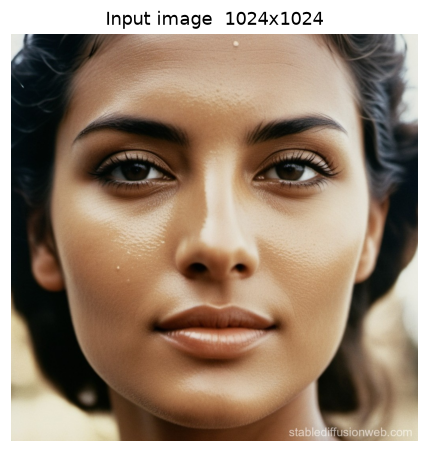

In [2]:
# ── Option A: use your own image ──────────────────────────────────────────
# IMAGE_PATH = 'D:\\Misc\\Purnazen-Android-App\\backend\\uploads\\test\\face_test_3.jpg'
# IMAGE_PATH = 'D:\\Misc\\Purnazen-Android-App\\backend\\sandbox\\wrinklyFace001.jpg'
IMAGE_PATH = 'D:\\Misc\\Purnazen-Android-App\\backend\\sandbox\\oilyFace002.jpg'
img_bgr = cv2.imread(IMAGE_PATH)

# # ── Option B: synthetic face (no real image needed) ───────────────────────
# def make_face(h=640, w=480, skin=(110, 155, 210)):
#     img = np.zeros((h, w, 3), dtype=np.uint8)
#     img[:] = (int(skin[0]*0.6), int(skin[1]*0.6), int(skin[2]*0.6))
#     cv2.ellipse(img, (w//2, int(h*0.42)), (int(w*0.32), int(h*0.38)), 0, 0, 360, skin, -1)
#     noise = np.random.normal(0, 8, img.shape).astype(np.int16)
#     return np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

# img_bgr = make_face()
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(4, 5))
plt.imshow(img_rgb)
plt.title(f'Input image  {img_bgr.shape[1]}x{img_bgr.shape[0]}')
plt.axis('off')
plt.tight_layout()
plt.show()

## 2. Pre-processing: Resize · Blur Gate · Lighting

In [3]:
from app.ai.image_preprocessor import resize_for_analysis, detect_blur, detect_lighting

img = resize_for_analysis(img_bgr, max_width=800)
blur_score  = detect_blur(img)
lighting    = detect_lighting(img)

print(f'Shape after resize : {img.shape}')
print(f'Blur score         : {blur_score:.1f}  (>= 30 = acceptable)')
print(f'Lighting quality   : {lighting}')

if blur_score < 30:
    print('⚠️  Image is too blurry — results may be inaccurate')

Shape after resize : (800, 800, 3)
Blur score         : 68.3  (>= 30 = acceptable)
Lighting quality   : good


## 3. Face Detection

In [4]:
from app.services.scan_pipeline_service import _detect_face_opencv, _rois_from_bbox

landmarks = []
rois = None
using_fallback = False

try:
    from app.ai.face_detector import get_face_detector
    from app.ai.image_preprocessor import extract_rois
    landmarks, conf = get_face_detector().detect(img)
    print(f'✓ MediaPipe: {len(landmarks)} landmarks  confidence={conf:.2f}')
    if landmarks:
        rois = extract_rois(img, landmarks)
except RuntimeError as e:
    print(f'⚠️  MediaPipe unavailable: {e}')
    using_fallback = True

if rois is None:
    bbox = _detect_face_opencv(img)
    if bbox:
        x, y, w, h = bbox
        print(f'✓ OpenCV Haar: face at ({x},{y}) size {w}x{h}')
        rois = _rois_from_bbox(img, x, y, w, h)

        # Visualise bounding box
        vis = img_rgb.copy()
        vis_bgr = img.copy()
        cv2.rectangle(vis_bgr, (x,y), (x+w, y+h), (200,80,200), 2)
        vis = cv2.cvtColor(vis_bgr, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(4,5))
        plt.imshow(vis)
        plt.title('Detected face bounding box')
        plt.axis('off')
        plt.show()
    else:
        print('✗ No face detected — check the image')

print('ROIs available:', list(rois.keys()) if rois else 'NONE')

✓ MediaPipe: 478 landmarks  confidence=0.95
ROIs available: ['forehead', 'left_cheek', 'right_cheek', 'under_eye_l', 'under_eye_r', 't_zone', 'jawline', 'eye_corners_l', 'eye_corners_r', 'temples_l', 'temples_r']


## 4. Visualise ROI Crops

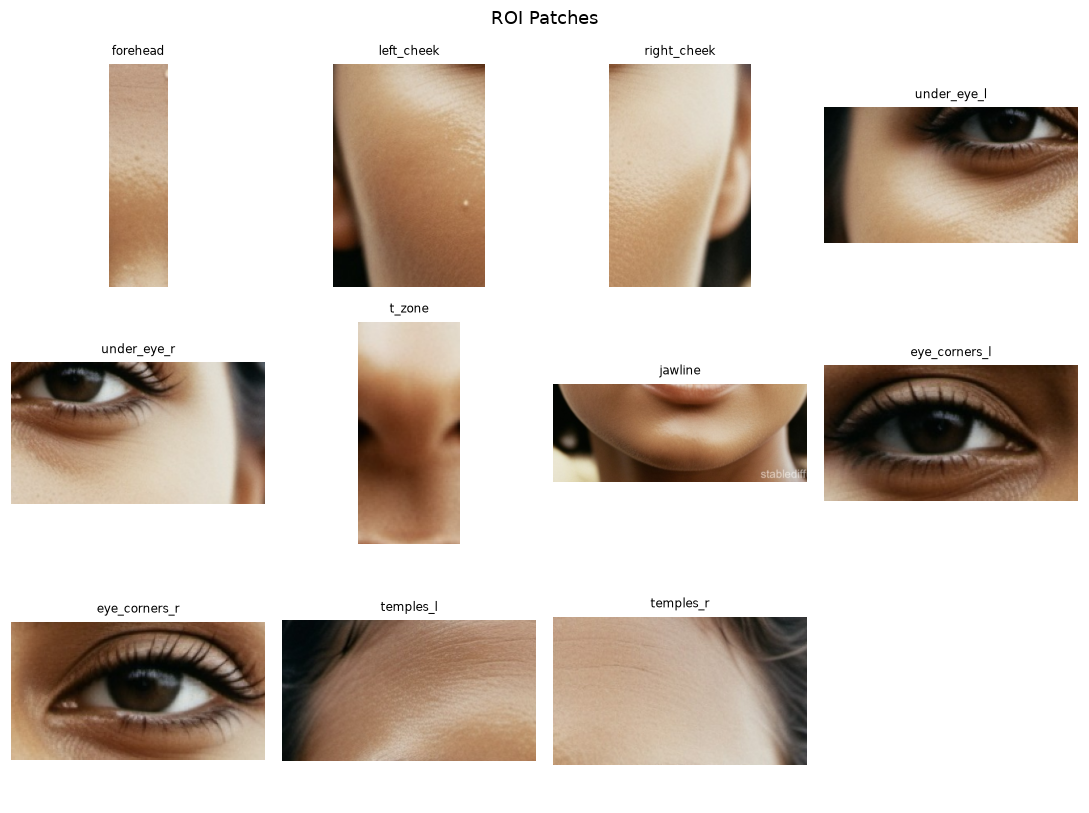

In [5]:
if rois:
    names = list(rois.keys())
    n = len(names)
    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2.5, rows*2.5))
    axes = axes.flatten()
    for i, name in enumerate(names):
        patch = rois[name]
        if patch is not None:
            axes[i].imshow(cv2.cvtColor(patch, cv2.COLOR_BGR2RGB))
        else:
            axes[i].text(0.5, 0.5, 'None', ha='center', va='center', color='red')
        axes[i].set_title(name, fontsize=8)
        axes[i].axis('off')
    for j in range(n, len(axes)):
        axes[j].axis('off')
    plt.suptitle('ROI Patches', fontsize=12)
    plt.tight_layout()
    plt.show()

## 5. Run All Analyzers

In [6]:
from app.ai.analyzers import (
    hydration_analyzer, oiliness_analyzer, wrinkle_analyzer,
    pigmentation_analyzer, dark_circle_analyzer, pore_analyzer,
    elasticity_analyzer, muscle_tone_analyzer, inflammation_analyzer,
    glow_score_engine, toxin_indicator,
)

def safe(fn, *args, default=50.0):
    try:
        return round(float(fn(*args)), 2)
    except Exception as e:
        print(f'  ⚠ {fn.__module__}: {e}')
        return default

scores = {}
if rois:
    scores = {
        'hydration':    safe(hydration_analyzer.analyze,    rois['left_cheek'],  rois['right_cheek']),
        'oiliness':     safe(oiliness_analyzer.analyze,     rois['t_zone']),
        'wrinkle':      safe(wrinkle_analyzer.analyze,      rois['forehead'],    rois['eye_corners_l']),
        'pigmentation': safe(pigmentation_analyzer.analyze,  img, rois['left_cheek'], rois['right_cheek']),
        'dark_circle':  safe(dark_circle_analyzer.analyze,   rois['under_eye_l'], rois['under_eye_r'], rois['left_cheek'], rois['right_cheek']),
        'pore':         safe(pore_analyzer.analyze,          rois['left_cheek'],  rois['right_cheek']),
        'elasticity':   safe(elasticity_analyzer.analyze,    rois['jawline'],     rois['forehead']),
        'muscle_tone':  safe(muscle_tone_analyzer.analyze,   landmarks, img.shape[0], img.shape[1]) if landmarks else 60.0,
        'inflammation': safe(inflammation_analyzer.analyze,  rois['left_cheek'],  rois['right_cheek'], rois['forehead']),
    }

for k, v in scores.items():
    bar = '█' * int(v / 5)
    print(f'  {k:<16} {v:5.1f}  {bar}')

  hydration         56.1  ███████████
  oiliness          76.5  ███████████████
  wrinkle           56.5  ███████████
  pigmentation      52.4  ██████████
  dark_circle       48.4  █████████
  pore               9.9  █
  elasticity        41.1  ████████
  muscle_tone       94.0  ██████████████████
  inflammation      32.4  ██████


## 6. Composite Scores: Glow · Toxin · Wellness

In [7]:
if scores:
    partial = {f'{k}_score': v for k, v in scores.items()}
    glow     = glow_score_engine.compute(partial)
    toxin    = toxin_indicator.compute(scores['dark_circle'], scores['oiliness'], glow)
    wellness = round(glow * 0.7 + (100 - toxin) * 0.3, 2)
    skin_age = int(np.clip(30 + (scores['wrinkle'] - 40)*0.3 - (scores['elasticity'] - 60)*0.2, 18, 70))

    print(f'  Glow score         : {glow:.1f} / 100')
    print(f'  Toxin indicator    : {toxin:.1f} / 100  (lower = better)')
    print(f'  Wellness score     : {wellness:.1f} / 100')
    print(f'  Estimated skin age : {skin_age} yrs')

  Glow score         : 53.6 / 100
  Toxin indicator    : 56.2 / 100  (lower = better)
  Wellness score     : 50.6 / 100
  Estimated skin age : 38 yrs


## 7. Radar Chart — Skin Profile

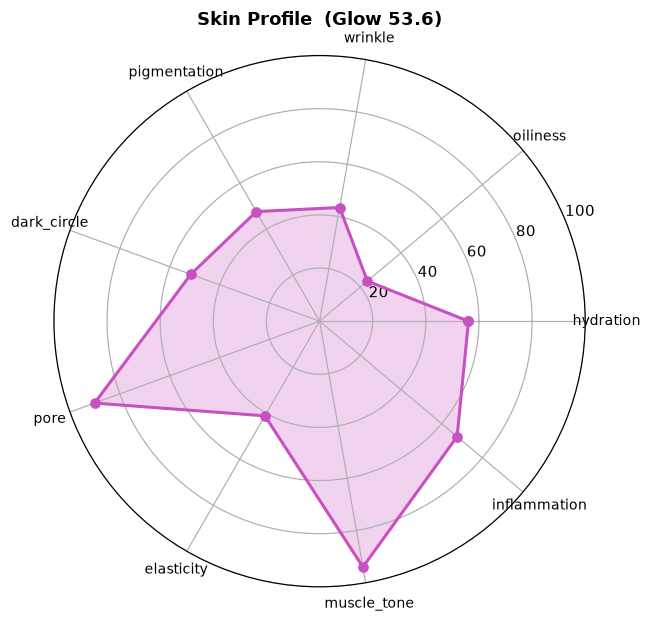

In [8]:
if scores:
    labels = list(scores.keys())
    values = [scores[l] for l in labels]

    # Invert "higher is worse" metrics so all axes mean "better"
    invert_keys = {'oiliness', 'wrinkle', 'pigmentation', 'dark_circle', 'pore', 'inflammation'}
    plot_values = [100 - v if l in invert_keys else v for l, v in zip(labels, values)]

    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    plot_values += plot_values[:1]
    angles      += angles[:1]

    fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
    ax.plot(angles, plot_values, 'o-', linewidth=2, color='#C850C0')
    ax.fill(angles, plot_values, alpha=0.25, color='#C850C0')
    ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=9)
    ax.set_ylim(0, 100)
    ax.set_yticks([20, 40, 60, 80, 100])
    ax.set_title(f'Skin Profile  (Glow {glow:.1f})', pad=20, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 8. Recommendation Engine Preview

In [9]:
import types
from app.services import recommendation_engine_service

if scores:
    result_ns = types.SimpleNamespace(
        **{f'{k}_score': v for k, v in scores.items()},
        glow_score=glow,
        toxin_indicator=toxin,
        overall_wellness_score=wellness,
    )
    recs = recommendation_engine_service.generate(result_ns)
    print(f'{len(recs)} recommendation(s) generated:\n')
    for i, r in enumerate(recs, 1):
        print(f'  {i}. [{r["tip_category"]}] {r["title"]}')
        print(f'     {r["description"][:80]}…')
        print()

2 recommendation(s) generated:

  1. [nutrition] Firm & Renew
     Fine lines with reduced elasticity indicate Yin and Blood deficiency. Support co…

  2. [nutrition] Reduce Dairy
     Excess oiliness is linked to Dampness-heat in TCM. Reducing dairy and greasy foo…



## 9. Quick Analyzer Benchmarks

Measure runtime for each analyzer to identify slow paths.

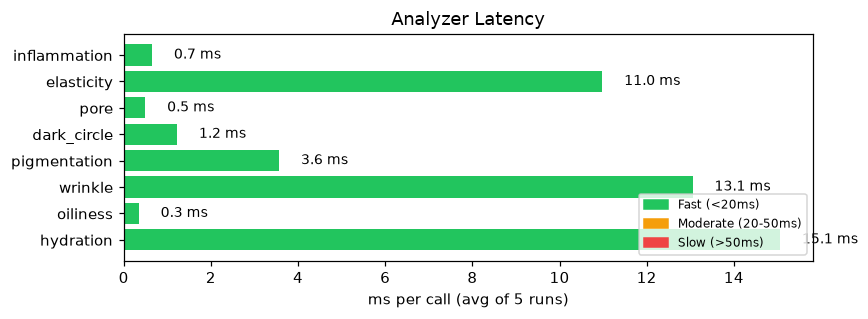

In [10]:
import time

ANALYZER_CALLS = [
    ('hydration',    lambda: hydration_analyzer.analyze(rois['left_cheek'], rois['right_cheek'])),
    ('oiliness',     lambda: oiliness_analyzer.analyze(rois['t_zone'])),
    ('wrinkle',      lambda: wrinkle_analyzer.analyze(rois['forehead'], rois['eye_corners_l'])),
    ('pigmentation', lambda: pigmentation_analyzer.analyze(img, rois['left_cheek'], rois['right_cheek'])),
    ('dark_circle',  lambda: dark_circle_analyzer.analyze(rois['under_eye_l'], rois['under_eye_r'], rois['left_cheek'], rois['right_cheek'])),
    ('pore',         lambda: pore_analyzer.analyze(rois['left_cheek'], rois['right_cheek'])),
    ('elasticity',   lambda: elasticity_analyzer.analyze(rois['jawline'], rois['forehead'])),
    ('inflammation', lambda: inflammation_analyzer.analyze(rois['left_cheek'], rois['right_cheek'], rois['forehead'])),
]

N = 5
timings = {}

if rois:
    for name, fn in ANALYZER_CALLS:
        try:
            t = time.perf_counter()
            for _ in range(N): fn()
            timings[name] = (time.perf_counter() - t) / N * 1000
        except Exception as e:
            timings[name] = -1
            print(f'  {name}: FAILED ({e})')

    names_t = list(timings.keys())
    ms_t    = [timings[k] for k in names_t]
    colors  = ['#ef4444' if v > 50 else '#f59e0b' if v > 20 else '#22c55e' for v in ms_t]

    fig, ax = plt.subplots(figsize=(8, 3))
    bars = ax.barh(names_t, ms_t, color=colors)
    ax.set_xlabel('ms per call (avg of 5 runs)')
    ax.set_title('Analyzer Latency')
    for bar, val in zip(bars, ms_t):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f} ms', va='center', fontsize=9)
    patches = [
        mpatches.Patch(color='#22c55e', label='Fast (<20ms)'),
        mpatches.Patch(color='#f59e0b', label='Moderate (20-50ms)'),
        mpatches.Patch(color='#ef4444', label='Slow (>50ms)'),
    ]
    ax.legend(handles=patches, fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.show()